In [15]:
import pandas as pd

hb = pd.read_csv("C:\\Users\\Madivoli Analytics\\OneDrive\\Documents\\Projects\\Hotel Bookings\\hotel_bookings.csv")

print(hb.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [ ]:
-- Checking data types

In [16]:
hb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
--Checking missing values

In [10]:
hb.isna().any()

hotel                             False
is_canceled                       False
lead_time                         False
arrival_date_year                 False
arrival_date_month                False
arrival_date_week_number          False
arrival_date_day_of_month         False
stays_in_weekend_nights           False
stays_in_week_nights              False
adults                            False
children                           True
babies                            False
meal                              False
country                            True
market_segment                    False
distribution_channel              False
is_repeated_guest                 False
previous_cancellations            False
previous_bookings_not_canceled    False
reserved_room_type                False
assigned_room_type                False
booking_changes                   False
deposit_type                      False
agent                              True
company                            True


In [17]:
hb.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

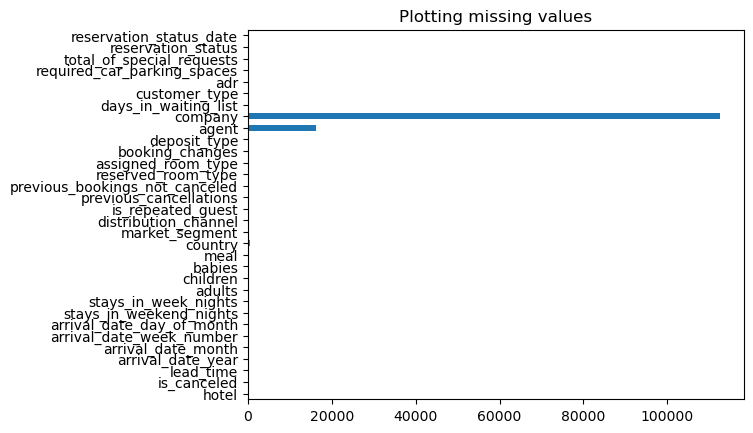

In [18]:
import matplotlib.pyplot as plt 

hb.isna().sum().plot(title="Plotting missing values", kind="barh")
plt.show()

In [ ]:
--Data cleaning and processing

In [43]:
import pandas as pd
import numpy as np

# Replacing missing values
hb['children'] = hb['children'].fillna(0)
hb['country'] = hb['country'].fillna('Unknown')
hb['agent'] = hb['agent'].fillna('No Agent')
hb['company'] = hb['company'].fillna('No Company')

In [44]:
# 2. Converting data types
# Categorical Columns
cat_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
           'distribution_channel', 'reserved_room_type', 'assigned_room_type',
           'deposit_type', 'agent', 'company', 'customer_type', 'reservation_status']
hb[cat_cols] = hb[cat_cols].astype('category')

In [21]:
# Boolean Columns
hb['is_canceled'] = hb['is_canceled'].astype('bool')
hb['is_repeated_guest'] = hb['is_repeated_guest'].astype('bool')

In [22]:
# Integer Columns
int_cols = ['arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
            'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'babies',
            'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
            'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']
hb[int_cols] = hb[int_cols].astype('int16') 

In [23]:
# Specific smaller-range integers
hb[['arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
    'stays_in_week_nights', 'adults', 'babies', 'booking_changes', 
    'required_car_parking_spaces', 'total_of_special_requests']] = hb[['arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'babies', 'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests']].astype('int8')

In [24]:
# Float Columns
hb['adr'] = hb['adr'].astype('float32')
hb['children'] = hb['children'].astype('int8') # Now that nulls are filled with 0

In [25]:
# Date Column
hb['reservation_status_date'] = pd.to_datetime(hb['reservation_status_date'])

In [26]:
# 3. Feature Engineering

# String concatenation for arrival date
hb['arrival_date'] = pd.to_datetime(
    hb['arrival_date_year'].astype(str) + '-' + 
    hb['arrival_date_month'].astype(str) + '-' + 
    hb['arrival_date_day_of_month'].astype(str)
)

In [27]:
# Converting month back to category
hb['arrival_date_month'] = hb['arrival_date_month'].astype('category')

In [28]:
# Calculating derived features
hb['stays_total_nights'] = hb['stays_in_weekend_nights'] + hb['stays_in_week_nights']
hb['total_guests'] = hb['adults'] + hb['children'] + hb['babies']

In [29]:
# Creating lead time bin groups
bins = [-1, 0, 7, 30, 90, 900]
labels = ['Same Day', '1-7 Days', '8-30 Days', '31-90 Days', '90+ Days']
hb['lead_time_group'] = pd.cut(hb['lead_time'], bins=bins, labels=labels).astype('category')

In [30]:
# Creating boolean flags
hb['has_booking_changes'] = (hb['booking_changes'] > 0)
hb['has_special_requests'] = (hb['total_of_special_requests'] > 0)
hb['was_on_waiting_list'] = (hb['days_in_waiting_list'] > 0)

In [28]:
# Room type comparison
hb['is_room_assigned_different'] = (hb['reserved_room_type'].astype(str) != hb['assigned_room_type'].astype(str))

In [31]:
# Verify no guests == 0 (data integrity check)
zero_guest_bookings = (hb['total_guests'] == 0).sum()
print(f"Bookings with zero guests: {zero_guest_bookings}")

if zero_guest_bookings > 0:
    print("Warning: There are bookings with zero guests. These may need investigation.")

Bookings with zero guests: 180


In [32]:
# Investigating further the zero guest bookings
zero_guest_mask = hb['total_guests'] == 0
zero_guest_bookings = hb[zero_guest_mask]

print("--- Zero Guest Bookings Analysis ---")
print(f"Total zero guest bookings: {len(zero_guest_bookings)}")
print("\nBreakdown by hotel type:")
print(zero_guest_bookings['hotel'].value_counts())
print("\nBreakdown by reservation status:")
print(zero_guest_bookings['reservation_status'].value_counts())
print("\nSample of zero guest bookings:")
print(zero_guest_bookings[['hotel', 'adults', 'children', 'babies', 'reservation_status', 'adr']].head(10))

--- Zero Guest Bookings Analysis ---
Total zero guest bookings: 180

Breakdown by hotel type:
hotel
City Hotel      167
Resort Hotel     13
Name: count, dtype: int64

Breakdown by reservation status:
reservation_status
Check-Out    155
Canceled      24
No-Show        1
Name: count, dtype: int64

Sample of zero guest bookings:
              hotel  adults  children  babies reservation_status   adr
2224   Resort Hotel       0         0       0          Check-Out   0.0
2409   Resort Hotel       0         0       0          Check-Out   0.0
3181   Resort Hotel       0         0       0          Check-Out   0.0
3684   Resort Hotel       0         0       0          Check-Out   0.0
3708   Resort Hotel       0         0       0          Check-Out   0.0
4127   Resort Hotel       0         0       0           Canceled   0.0
9376   Resort Hotel       0         0       0           Canceled   0.0
31765  Resort Hotel       0         0       0          Check-Out  28.0
32029  Resort Hotel       0      

In [34]:
# Final cleaning
# Removing clearly invalid zero bookings, flag the rest
print("--- Implementing Final Data Cleaning ---")

# Remove only the clearly problematic zero-guest bookings
to_remove_mask = (
    (hb['total_guests'] == 0) & 
    (hb['reservation_status'].isin(['Canceled', 'No-Show']) | (hb['adr'] > 0))
)

hb_clean = hb[~to_remove_mask].copy()

--- Implementing Final Data Cleaning ---


In [35]:
# Creating analysis flags
hb_clean['is_complimentary'] = (hb_clean['total_guests'] == 0) & (hb_clean['adr'] == 0)
hb_clean['is_potential_issue'] = (hb_clean['total_guests'] == 0)

print(f"Removed {to_remove_mask.sum()} invalid zero-guest bookings")
print(f"Kept {hb_clean['is_complimentary'].sum()} potential complimentary stays")
print(f"Final dataset size: {len(hb_clean):,} bookings")

Removed 56 invalid zero-guest bookings
Kept 124 potential complimentary stays
Final dataset size: 119,334 bookings


In [33]:
# Final data quality report
print("\n=== FINAL DATA QUALITY REPORT ===")
print(f"Total bookings: {len(hb_clean):,}")
print(f"Zero guest bookings: {(hb_clean['total_guests'] == 0).sum()}")
print(f"Cancelation rate: {hb_clean['is_canceled'].mean():.2%}")
print(f"Memory usage: {hb_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


=== FINAL DATA QUALITY REPORT ===
Total bookings: 119,334
Zero guest bookings: 124
Cancelation rate: 37.04%
Memory usage: 9.27 MB


In [36]:
# Verifying key business metrics still make sense
print("\n--- Business Metrics Validation ---")
print("Revenue by Hotel (excluding complimentary):")
valid_revenue = hb_clean[hb_clean['adr'] > 0]
revenue_by_hotel = valid_revenue.groupby('hotel', observed=True).apply(
    lambda x: (x['adr'] * (x['stays_in_weekend_nights'] + x['stays_in_week_nights'])).sum(),
    include_groups=False
)
print(revenue_by_hotel)


--- Business Metrics Validation ---
Revenue by Hotel (excluding complimentary):
hotel
City Hotel      25270400.0
Resort Hotel    17443812.0
dtype: float32


In [ ]:
# Saving the final optimized dataset

In [37]:
import os
documents_path = os.path.join(os.path.expanduser('~'), 'Documents')
documents_file = os.path.join(documents_path, 'hotel_bookings_optimized_cleaned.csv')
hb_clean.to_csv(documents_file, index=False)
print(f"✅ Saved to Documents: {documents_file}")

✅ Saved to Documents: C:\Users\Madivoli Analytics\Documents\hotel_bookings_optimized_cleaned.csv


In [38]:
import pandas as pd

# Read from CSV 
hb = pd.read_csv(r"C:\Users\Madivoli Analytics\OneDrive\Documents\Projects\Hotel Bookings\hotel_bookings_optimized_cleaned.csv") 
total_bookings = len(hb)
print(f"Total bookings: {total_bookings}")

Total bookings: 119334


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hb = pd.read_csv("C:\\Users\\Madivoli Analytics\\OneDrive\\Documents\\Projects\\Hotel Bookings\\bookings_analysis.csv")

In [40]:
# Displaying basic info about the dataset
print("Dataset Info:")
print(hb.info())
print("\nFirst 5 rows:")
print(hb.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119334 entries, 0 to 119333
Data columns (total 43 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel_type                      119334 non-null  object 
 1   is_canceled                     119334 non-null  bool   
 2   lead_time                       119334 non-null  int64  
 3   arrival_date_year               119334 non-null  int64  
 4   arrival_date_month              119334 non-null  object 
 5   arrival_date_week_number        119334 non-null  int64  
 6   arrival_date_day_of_month       119334 non-null  int64  
 7   stays_in_weekend_nights         119334 non-null  int64  
 8   stays_in_week_nights            119334 non-null  int64  
 9   adults                          119334 non-null  int64  
 10  children                        119334 non-null  int64  
 11  babies                          119334 non-null  int64  
 12  me

In [41]:
# Calculating Key Performance Metrics
print("\n" + "="*50)
print("KEY METRICS ANALYSIS")
print("="*50)

# 1. Average ADR (Average Daily Rate)
avg_adr = hb['adr'].mean().round()
print(f"\n1. Average ADR: ${avg_adr:.2f}")


KEY METRICS ANALYSIS

1. Average ADR: $102.00


In [42]:
# 2. Average Lead Time
avg_lead_time = hb['lead_time'].mean().round()
print(f"2. Average Lead Time: {avg_lead_time:.1f} days")

2. Average Lead Time: 104.0 days


In [43]:
# 3. Cancellation Rate
total_bookings = len(hb)
cancelled_bookings = hb['is_canceled'].sum()
cancellation_rate = (cancelled_bookings / total_bookings) * 100
print(f"3. Cancellation Rate: {cancellation_rate:.2f}%")

3. Cancellation Rate: 37.04%


In [44]:
# 4. Average Total of Special Requests
avg_special_requests = hb['total_of_special_requests'].mean()
print(f"4. Average Special Requests: {avg_special_requests:.2f} per booking")

4. Average Special Requests: 0.57 per booking



5. Top 10 Source Countries by Bookings:
   Portugal: 48564 bookings (40.70%)
   United Kingdom: 12125 bookings (10.16%)
   France: 10413 bookings (8.73%)
   Spain: 8567 bookings (7.18%)
   Germany: 7287 bookings (6.11%)
   Italy: 3766 bookings (3.16%)
   Ireland: 3375 bookings (2.83%)
   Belgium: 2342 bookings (1.96%)
   China: 2278 bookings (1.91%)
   Brazil: 2223 bookings (1.86%)


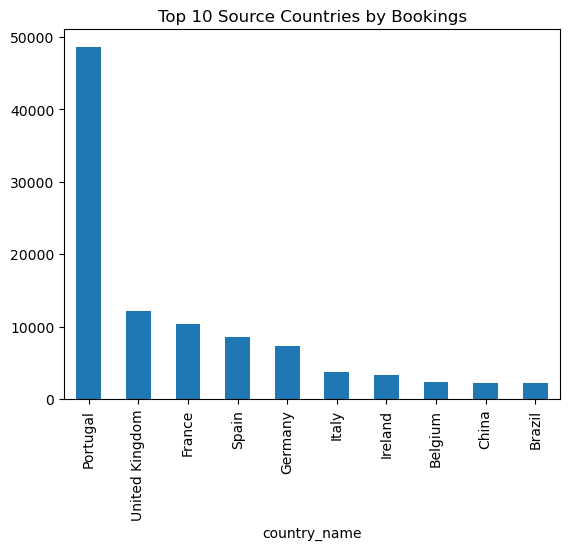

In [45]:
# 5. Top Countries (by number of bookings)
top_countries = hb['country_name'].value_counts().head(10)
print(f"\n5. Top 10 Source Countries by Bookings:")
for country, count in top_countries.items():
    percentage = (count / total_bookings) * 100
    print(f"   {country}: {count} bookings ({percentage:.2f}%)")

import matplotlib.pyplot as plt
top_countries.plot(kind="bar", title="Top 10 Source Countries by Bookings")
plt.show()


6. Average Lead Time by Top 10 Source Countries:
   Germany: 137.4 days
   United Kingdom: 127.5 days
   Ireland: 120.4 days
   Portugal: 115.6 days
   Belgium: 99.7 days
   Italy: 90.7 days
   China: 85.5 days
   Brazil: 83.3 days
   France: 82.3 days
   Spain: 54.9 days


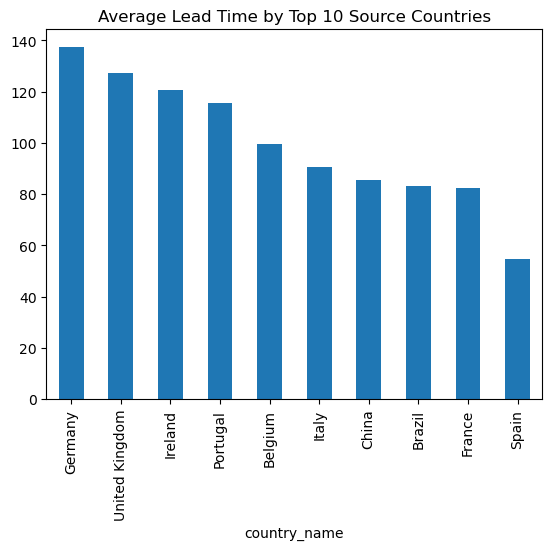

In [49]:
# 6. Top Countries (by Average lead time)

print(f"\n6. Average Lead Time by Top 10 Source Countries:")
top_countries_list = top_countries.index.tolist()  
lead_time_by_country = hb[hb['country_name'].isin(top_countries_list)].groupby('country_name')['lead_time'].mean().sort_values(ascending=False)

for country, avg_lead_time in lead_time_by_country.items():
    print(f"   {country}: {avg_lead_time:.1f} days")


import matplotlib.pyplot as plt
lead_time_by_country.plot(kind="bar", title="Average Lead Time by Top 10 Source Countries")
plt.show()

In [102]:
# 3. Cancellation Rate
total_bookings = len(hb)
cancelled_bookings = hb['is_canceled'].sum()
cancellation_rate = (cancelled_bookings / total_bookings) * 100
print(f"3. Cancellation Rate: {cancellation_rate:.2f}%")

top_countries_list = top_countries.index.tolist()  
cancellation_rate_by_country = hb[hb['country_name'].isin(top_countries_list)].groupby('country_name')['cancellation_rate'].sort_values(ascending=False)


3. Cancellation Rate: 37.04%


KeyError: 'Column not found: cancellation_rate'

In [51]:
top_countries = hb['country_name'].value_counts().head(10)
print(top_countries)

country_name
Portugal          48564
United Kingdom    12125
France            10413
Spain              8567
Germany            7287
Italy              3766
Ireland            3375
Belgium            2342
China              2278
Brazil             2223
Name: count, dtype: int64


In [52]:
# Calculating KPIs segmented by hotel type
if 'hotel_type' in hb.columns:
    print("\n" + "="*50)
    print("METRICS BY HOTEL TYPE")
    print("="*50)
    
    metrics_by_hotel = hb.groupby('hotel_type').agg({
        'adr': 'mean',
        'lead_time': 'mean',
        'is_canceled': lambda x: (x.sum() / len(x)) * 100,
        'total_of_special_requests': 'mean'
    }).round(2)
    
    metrics_by_hotel.columns = ['Avg_ADR', 'Avg_Lead_Time_Days', 'Cancellation_Rate_%', 'Avg_Special_Requests']
    print(metrics_by_hotel)


METRICS BY HOTEL TYPE
              Avg_ADR  Avg_Lead_Time_Days  Cancellation_Rate_%  \
hotel_type                                                       
City Hotel     105.35              109.76                41.73   
Resort Hotel    94.96               92.68                27.76   

              Avg_Special_Requests  
hotel_type                          
City Hotel                    0.55  
Resort Hotel                  0.62  


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Portugal'),
  Text(1, 0, 'United Kingdom'),
  Text(2, 0, 'France'),
  Text(3, 0, 'Spain'),
  Text(4, 0, 'Germany')])

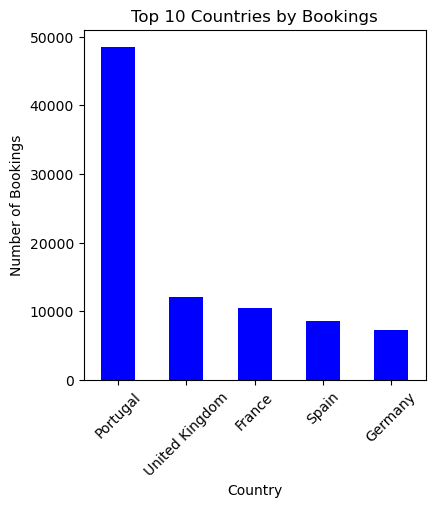

In [53]:
# Visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Top Countries
plt.subplot(2, 3, 1)
top_countries.head(5).plot(kind='bar', color='blue')
plt.title('Top 10 Countries by Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)

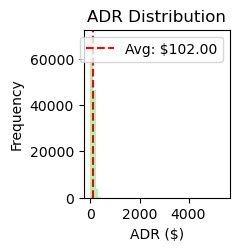

In [54]:
# Plot 2: ADR Distribution
plt.subplot(2, 3, 2)
plt.hist(hb['adr'].dropna(), bins=50, color='lightgreen', alpha=0.7)
plt.axvline(avg_adr, color='red', linestyle='--', label=f'Avg: ${avg_adr:.2f}')
plt.title('ADR Distribution')
plt.xlabel('ADR ($)')
plt.ylabel('Frequency')
plt.legend()

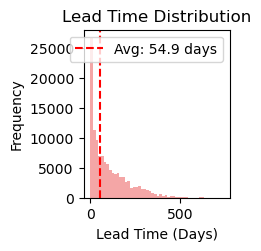

In [55]:
# Plot 3: Lead Time Distribution
plt.subplot(2, 3, 3)
plt.hist(hb['lead_time'].dropna(), bins=50, color='lightcoral', alpha=0.7)
plt.axvline(avg_lead_time, color='red', linestyle='--', label=f'Avg: {avg_lead_time:.1f} days')
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.legend()

Text(0.5, 1.0, 'Cancellation Rate: 37.04%')

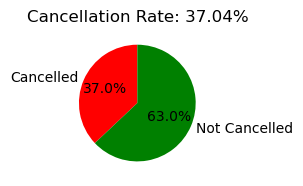

In [42]:
# Plot 4: Cancellation Rate
plt.subplot(2, 3, 4)
cancel_data = [cancelled_bookings, total_bookings - cancelled_bookings]
labels = ['Cancelled', 'Not Cancelled']
colors = ['red', 'green']
plt.pie(cancel_data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Cancellation Rate: {cancellation_rate:.2f}%')

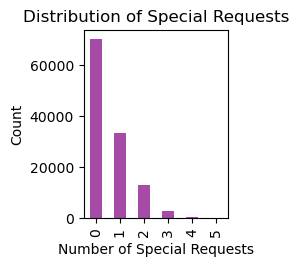

In [56]:
# Plot 5: Special Requests
plt.subplot(2, 3, 5)
special_requests_counts = hb['total_of_special_requests'].value_counts().sort_index()
special_requests_counts.plot(kind='bar', color='purple', alpha=0.7)
plt.title('Distribution of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [57]:
# Further analysis
print("\n" + "="*50)
print("FURTHER ANALYSIS")
print("="*50)

# Correlation between lead time and cancellation
correlation_lead_cancel = hb[['lead_time', 'is_canceled']].corr().iloc[0,1]
print(f"Correlation between Lead Time and Cancellation: {correlation_lead_cancel:.3f}")


FURTHER ANALYSIS
Correlation between Lead Time and Cancellation: 0.293


In [58]:
# ADR by cancellation status 
adr_by_cancel = hb.groupby('is_canceled')['adr'].mean()
print(f"\nAverage ADR by Cancellation Status:")

print(f"  Not Cancelled: ${adr_by_cancel.iloc[0]:.2f}")
print(f"  Cancelled: ${adr_by_cancel.iloc[1]:.2f}")


Average ADR by Cancellation Status:
  Not Cancelled: $100.00
  Cancelled: $105.02


In [59]:
# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Total Bookings: {total_bookings:,}")
print(f"  Cancelled Bookings: {cancelled_bookings:,}")
print(f"  Non-Cancelled Bookings: {total_bookings - cancelled_bookings:,}")


Summary Statistics:
  Total Bookings: 119,334
  Cancelled Bookings: 44,199
  Non-Cancelled Bookings: 75,135


In [60]:
# Additional metrics
print(f"\nAdditional Metrics:")

# Revenue analysis (assuming ADR represents daily revenue)
total_potential_revenue = hb['adr'].sum()
actual_revenue = hb[hb['is_canceled'] == 0]['adr'].sum()
lost_revenue_due_to_cancellations = hb[hb['is_canceled'] == 1]['adr'].sum()

print(f"  Total Potential Revenue: ${total_potential_revenue:,.2f}")
print(f"  Actual Revenue: ${actual_revenue:,.2f}")
print(f"  Lost Revenue due to Cancellations: ${lost_revenue_due_to_cancellations:,.2f}")


Additional Metrics:
  Total Potential Revenue: $12,155,735.43
  Actual Revenue: $7,513,792.76
  Lost Revenue due to Cancellations: $4,641,942.67


In [61]:
# Lead time analysis by cancellation status
lead_time_by_cancel = hb.groupby('is_canceled')['lead_time'].agg(['mean', 'median'])
print(f"\nLead Time Analysis (in days):")
print(f"  Not Cancelled - Mean: {lead_time_by_cancel.iloc[0, 0]:.1f}, Median: {lead_time_by_cancel.iloc[0, 1]:.1f}")
print(f"  Cancelled - Mean: {lead_time_by_cancel.iloc[1, 0]:.1f}, Median: {lead_time_by_cancel.iloc[1, 1]:.1f}")


Lead Time Analysis (in days):
  Not Cancelled - Mean: 80.0, Median: 45.0
  Cancelled - Mean: 144.9, Median: 113.0


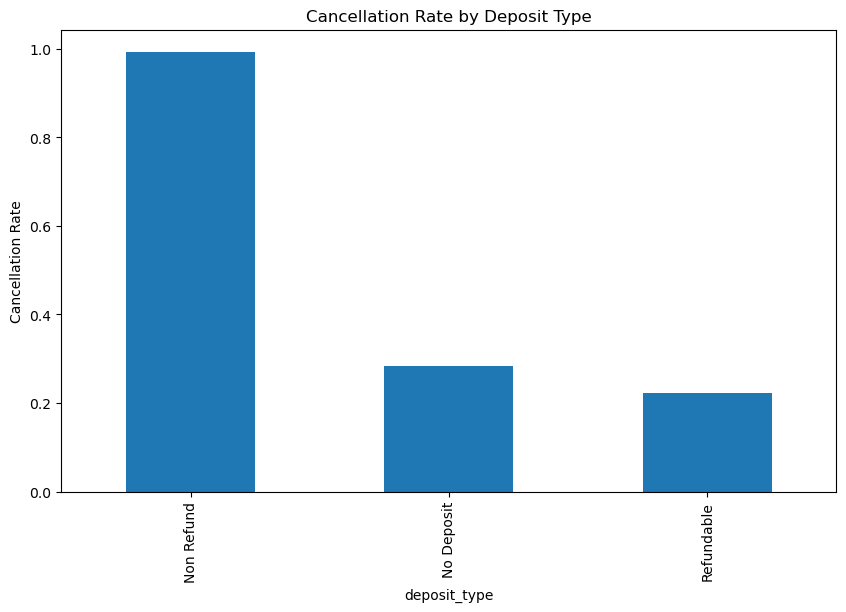

Cancellation rates by deposit type:
Non Refund: 99.36% (14587 bookings)
No Deposit: 28.37% (104585 bookings)
Refundable: 22.22% (162 bookings)


In [62]:
# Analyzing cancellation rates by deposit type
plt.figure(figsize=(10, 6))
deposit_cancel = hb.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
deposit_cancel.plot(kind='bar', title='Cancellation Rate by Deposit Type')
plt.ylabel('Cancellation Rate')
plt.show()

print("Cancellation rates by deposit type:")
for deposit_type, rate in deposit_cancel.items():
    count = hb[hb['deposit_type'] == deposit_type].shape[0]
    print(f"{deposit_type}: {rate:.2%} ({count} bookings)")

In [63]:
# Calculating effectiveness metrics for market segments
segment_analysis = hb.groupby('market_segment').agg({
    'is_canceled': ['count', 'sum', 'mean'],
    'adr': 'mean',
    'lead_time': 'mean'
}).round(4)

segment_analysis.columns = ['total_bookings', 'cancellations', 'cancellation_rate', 'avg_adr', 'avg_lead_time']
segment_analysis['non_canceled_bookings'] = segment_analysis['total_bookings'] - segment_analysis['cancellations']
segment_analysis['success_rate'] = 1 - segment_analysis['cancellation_rate']
segment_analysis['booking_share'] = (segment_analysis['total_bookings'] / len(hb)) * 100

# Calculating effectiveness score (weighted by volume and success rate)
segment_analysis['effectiveness_score'] = (
    segment_analysis['success_rate'] * segment_analysis['booking_share'] * segment_analysis['avg_adr']
)

# Sort by effectiveness (highest success + volume + revenue)
segment_effectiveness = segment_analysis.sort_values('effectiveness_score', ascending=False)

print("MARKET SEGMENT EFFECTIVENESS RANKING:")
print("="*70)
for idx, row in segment_effectiveness.iterrows():
    print(f"{idx:<15} | Success: {row['success_rate']:.2%} | Bookings: {row['non_canceled_bookings']:>5.0f} | "
          f"ADR: ${row['avg_adr']:>6.2f} | Score: {row['effectiveness_score']:>8.1f}")

MARKET SEGMENT EFFECTIVENESS RANKING:
Online TA       | Success: 63.27% | Bookings: 35717 | ADR: $117.23 | Score:   3508.6
Offline TA/TO   | Success: 65.71% | Bookings: 15906 | ADR: $ 87.39 | Score:   1164.8
Direct          | Success: 84.65% | Bookings: 10667 | ADR: $115.46 | Score:   1032.0
Groups          | Success: 38.94% | Bookings:  7713 | ADR: $ 79.50 | Score:    513.8
Corporate       | Success: 81.27% | Bookings:  4301 | ADR: $ 69.40 | Score:    250.1
Aviation        | Success: 78.06% | Bookings:   185 | ADR: $100.14 | Score:     15.5
Complementary   | Success: 87.89% | Bookings:   646 | ADR: $  2.92 | Score:      1.6
Undefined       | Success: 0.00% | Bookings:     0 | ADR: $ 15.00 | Score:      0.0


In [64]:
# Calculate effectiveness metrics for distribution channels
channel_analysis = hb.groupby('distribution_channel').agg({
    'is_canceled': ['count', 'sum', 'mean'],
    'adr': 'mean',
    'lead_time': 'mean',
    'is_repeated_guest': 'mean'
}).round(4)

channel_analysis.columns = ['total_bookings', 'cancellations', 'cancellation_rate', 'avg_adr', 'avg_lead_time', 'repeat_guest_rate']
channel_analysis['non_canceled_bookings'] = channel_analysis['total_bookings'] - channel_analysis['cancellations']
channel_analysis['success_rate'] = 1 - channel_analysis['cancellation_rate']
channel_analysis['booking_share'] = (channel_analysis['total_bookings'] / len(hb)) * 100

# Effectiveness score considering multiple factors
channel_analysis['effectiveness_score'] = (
    channel_analysis['success_rate'] * 
    channel_analysis['booking_share'] * 
    channel_analysis['avg_adr'] *
    (1 + channel_analysis['repeat_guest_rate'])  # Bonus for loyalty
)

# Sort by effectiveness
channel_effectiveness = channel_analysis.sort_values('effectiveness_score', ascending=False)

print("\nDISTRIBUTION CHANNEL EFFECTIVENESS RANKING:")
print("="*80)
for idx, row in channel_effectiveness.iterrows():
    print(f"{idx:<20} | Success: {row['success_rate']:.2%} | Non-canceled: {row['non_canceled_bookings']:>5.0f} | "
          f"ADR: ${row['avg_adr']:>6.2f} | Loyalty: {row['repeat_guest_rate']:.2%} | Score: {row['effectiveness_score']:>8.1f}")


DISTRIBUTION CHANNEL EFFECTIVENESS RANKING:
TA/TO                | Success: 58.97% | Non-canceled: 57694 | ADR: $103.32 | Loyalty: 1.32% | Score:   5060.8
Direct               | Success: 82.55% | Non-canceled: 12083 | ADR: $106.68 | Loyalty: 6.40% | Score:   1149.4
Corporate            | Success: 78.00% | Non-canceled:  5201 | ADR: $ 69.42 | Loyalty: 23.55% | Score:    373.8
GDS                  | Success: 80.83% | Non-canceled:   156 | ADR: $120.55 | Loyalty: 1.55% | Score:     16.0
Undefined            | Success: 20.00% | Non-canceled:     1 | ADR: $ 46.24 | Loyalty: 0.00% | Score:      0.0


In [95]:
# 1. Top countries by booking volume
top_countries = hb['country_name'].value_counts().head(10)
print("Top 10 Source Countries by Booking Volume:")
for country, count in top_countries.items():
    percentage = (count / len(hb)) * 100
    print(f"   {country}: {count} bookings ({percentage:.2f}%)")

# 2. Top countries by cancellation rate (only countries with significant volume)
country_cancel_rates = hb.groupby('country_name')['is_canceled'].agg(['mean', 'count'])
country_cancel_rates = country_cancel_rates[country_cancel_rates['count'] >= 100]  # Minimum 100 bookings
top_cancel_countries = country_cancel_rates.sort_values('mean', ascending=False).head(10)

print(f"\nTop 10 Countries by Cancellation Rate (min 100 bookings):")
for country, row in top_cancel_countries.iterrows():
    print(f"   {country}: {row['mean']:.2%} cancellation rate ({row['count']} bookings)")

# 3. Best countries (low cancellation, high volume)
best_countries = country_cancel_rates[
    (country_cancel_rates['count'] >= 500) &  # Good volume
    (country_cancel_rates['mean'] <= 0.20)    # Low cancellation
].sort_values(['mean', 'count'], ascending=[True, False])

print(f"\nBest Countries (Low Cancellation + High Volume):")
for country, row in best_countries.head(10).iterrows():
    print(f"   {country}: {row['mean']:.2%} cancellation rate ({row['count']} bookings)")

Top 10 Source Countries by Booking Volume:
   Portugal: 48564 bookings (40.70%)
   United Kingdom: 12125 bookings (10.16%)
   France: 10413 bookings (8.73%)
   Spain: 8567 bookings (7.18%)
   Germany: 7287 bookings (6.11%)
   Italy: 3766 bookings (3.16%)
   Ireland: 3375 bookings (2.83%)
   Belgium: 2342 bookings (1.96%)
   China: 2278 bookings (1.91%)
   Brazil: 2223 bookings (1.86%)

Top 10 Countries by Cancellation Rate (min 100 bookings):
   Portugal: 56.64% cancellation rate (48564.0 bookings)
   Angola: 56.63% cancellation rate (362.0 bookings)
   Morocco: 42.08% cancellation rate (259.0 bookings)
   South Korea: 41.35% cancellation rate (133.0 bookings)
   Turkey: 41.13% cancellation rate (248.0 bookings)
   Luxembourg: 38.11% cancellation rate (286.0 bookings)
   Russia: 37.94% cancellation rate (630.0 bookings)
   Brazil: 37.34% cancellation rate (2223.0 bookings)
   Italy: 35.40% cancellation rate (3766.0 bookings)
   Hungary: 33.48% cancellation rate (230.0 bookings)

Best C

In [96]:
# Analysis of lead time by country
lead_time_by_country = hb.groupby('country_name').agg({
    'lead_time': 'mean',
    'is_canceled': ['count', 'mean']
}).round(2)

lead_time_by_country.columns = ['avg_lead_time', 'total_bookings', 'cancellation_rate']
lead_time_by_country = lead_time_by_country[lead_time_by_country['total_bookings'] >= 100]

print("Countries by Average Lead Time:")
top_lead_time = lead_time_by_country.sort_values('avg_lead_time', ascending=False).head(10)
for country, row in top_lead_time.iterrows():
    print(f"   {country}: {row['avg_lead_time']:.0f} days lead time, {row['cancellation_rate']:.2%} cancellation")

Countries by Average Lead Time:
   Serbia: 142 days lead time, 3.00% cancellation
   Germany: 137 days lead time, 17.00% cancellation
   United Kingdom: 127 days lead time, 20.00% cancellation
   Australia: 125 days lead time, 25.00% cancellation
   Norway: 123 days lead time, 30.00% cancellation
   Ireland: 120 days lead time, 25.00% cancellation
   Austria: 118 days lead time, 18.00% cancellation
   Portugal: 116 days lead time, 57.00% cancellation
   Denmark: 113 days lead time, 25.00% cancellation
   Romania: 108 days lead time, 27.00% cancellation


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load data
hb = pd.read_csv("C:\\Users\\Madivoli Analytics\\OneDrive\\Documents\\Projects\\Hotel Bookings\\hotel_bookings_optimized_cleaned.csv")
print("Dataset shape:", hb.shape)

# Create derived features IN THE ORIGINAL DATAFRAME
hb['total_nights'] = hb['stays_in_weekend_nights'] + hb['stays_in_week_nights']
hb['total_guests'] = hb['adults'] + hb['children'].fillna(0) + hb['babies'].fillna(0)
hb['is_family'] = ((hb['children'].fillna(0) > 0) | (hb['babies'].fillna(0) > 0)).astype(int)
hb['is_weekend_heavy'] = (hb['stays_in_weekend_nights'] > hb['stays_in_week_nights']).astype(int)

# Select features for clustering
final_features = [
    'lead_time', 'total_nights', 'total_guests', 'adults', 
    'children', 'babies', 'previous_cancellations',
    'required_car_parking_spaces', 'total_of_special_requests', 
    'adr', 'is_repeated_guest', 'is_family', 'is_weekend_heavy'
]

# Create feature matrix
X = hb[final_features].copy()

# Handle any remaining missing values
X = X.fillna(0)

print("Final features for clustering:")
print(final_features)
print(f"Feature matrix shape: {X.shape}")

Dataset shape: (119334, 40)
Final features for clustering:
['lead_time', 'total_nights', 'total_guests', 'adults', 'children', 'babies', 'previous_cancellations', 'required_car_parking_spaces', 'total_of_special_requests', 'adr', 'is_repeated_guest', 'is_family', 'is_weekend_heavy']
Feature matrix shape: (119334, 13)


In [ ]:
STAGE 2: Data Preprocessing & Scaling

In [7]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Feature scaling completed")

Scaled data shape: (119334, 13)
Feature scaling completed


Testing optimal number of clusters...
Clusters: 2, WCSS: 1270699.17, Silhouette: 0.506
Clusters: 3, WCSS: 1143333.96, Silhouette: 0.501
Clusters: 4, WCSS: 1037645.78, Silhouette: 0.237
Clusters: 5, WCSS: 937275.21, Silhouette: 0.250
Clusters: 6, WCSS: 850585.97, Silhouette: 0.186
Clusters: 7, WCSS: 774810.63, Silhouette: 0.255


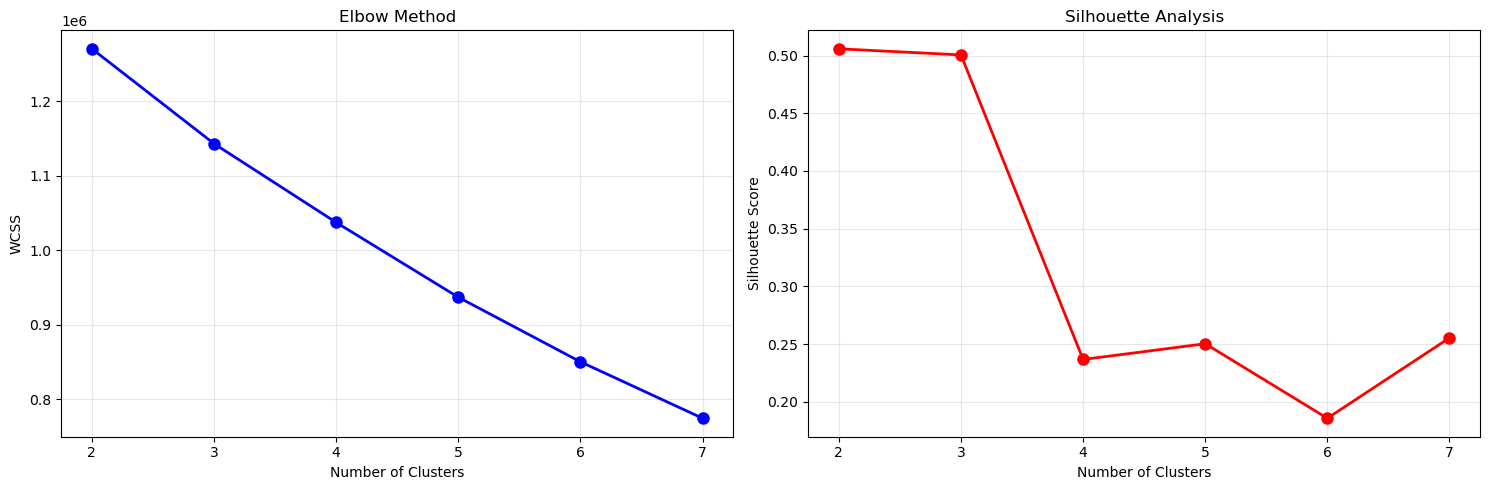

Selected optimal clusters: 5


In [8]:
# Test different numbers of clusters
wcss = []  # Within-cluster sum of squares
silhouette_scores = []
cluster_range = range(2, 8)

print("Testing optimal number of clusters...")
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    if k > 1:
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)
        print(f"Clusters: {k}, WCSS: {kmeans.inertia_:.2f}, Silhouette: {score:.3f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(cluster_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')
ax1.grid(True, alpha=0.3)

# Silhouette scores
ax2.plot(range(2, 8), silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal clusters (adjust based on plots)
optimal_clusters = 5
print(f"Selected optimal clusters: {optimal_clusters}")

In [9]:
# Perform K-means clustering
print("Performing K-means clustering...")
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to datasets
hb['cluster'] = clusters
X['cluster'] = clusters

print("Clustering completed!")
print("Cluster distribution:")
cluster_counts = hb['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(hb)) * 100
    print(f"Cluster {cluster_id}: {count} customers ({percentage:.1f}%)")

Performing K-means clustering...
Clustering completed!
Cluster distribution:
Cluster 0: 28982 customers (24.3%)
Cluster 1: 77297 customers (64.8%)
Cluster 2: 3759 customers (3.1%)
Cluster 3: 917 customers (0.8%)
Cluster 4: 8379 customers (7.0%)


In [12]:
# Analyze cluster characteristics
print("\n" + "="*50)
print("CLUSTER CHARACTERISTICS")
print("="*50)

# Verify all features exist in df
print("Available features in df:", [col for col in final_features if col in hb.columns])

cluster_stats = hb.groupby('cluster').agg({
    'lead_time': ['mean', 'median', 'std'],
    'total_nights': ['mean', 'median'],
    'total_guests': 'mean',
    'adults': 'mean', 
    'children': 'mean',
    'adr': ['mean', 'median'],
    'is_repeated_guest': 'mean',
    'is_family': 'mean',
    'total_of_special_requests': 'mean'
}).round(2)

print(cluster_stats)

# Add business context
business_context = hb.groupby('cluster').agg({
    'is_canceled': 'mean',
    'hotel': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'market_segment': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'customer_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'deposit_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed'
}).round(3)

business_context.columns = ['cancel_rate', 'hotel', 'segment', 'customer_type', 'deposit_type']
print("\nBUSINESS CONTEXT:")
print(business_context)


CLUSTER CHARACTERISTICS
Available features in df: ['lead_time', 'total_nights', 'total_guests', 'adults', 'children', 'babies', 'previous_cancellations', 'required_car_parking_spaces', 'total_of_special_requests', 'adr', 'is_repeated_guest', 'is_family', 'is_weekend_heavy']
        lead_time                total_nights        total_guests adults  \
             mean median     std         mean median         mean   mean   
cluster                                                                    
0           79.13   38.0   98.80         2.55    2.0         1.30   1.30   
1          118.69   87.0  110.15         3.77    3.0         2.07   2.07   
2           30.83    3.0   73.58         1.92    1.0         1.40   1.38   
3           77.63   47.0   82.64         4.16    4.0         3.25   1.99   
4           90.57   65.0   83.63         3.93    3.0         3.45   2.00   

        children     adr         is_repeated_guest is_family  \
            mean    mean  median              mean 

In [14]:
def create_customer_profiles(hb, optimal_clusters):
    profiles = []
    
    for cluster_id in range(optimal_clusters):
        cluster_data = hb[hb['cluster'] == cluster_id]
        
        profile = {
            'cluster': cluster_id,
            'size': len(cluster_data),
            'percentage': len(cluster_data) / len(hb) * 100,
            'avg_lead_time': cluster_data['lead_time'].mean(),
            'avg_stay_length': cluster_data['total_nights'].mean(),
            'avg_guests': cluster_data['total_guests'].mean(),
            'family_ratio': cluster_data['is_family'].mean(),
            'avg_adr': cluster_data['adr'].mean(),
            'repeat_guest_ratio': cluster_data['is_repeated_guest'].mean(),
            'special_requests_avg': cluster_data['total_of_special_requests'].mean(),
            'cancellation_rate': cluster_data['is_canceled'].mean(),
            'dominant_hotel': cluster_data['hotel'].mode()[0] if len(cluster_data['hotel'].mode()) > 0 else 'Mixed',
            'dominant_segment': cluster_data['market_segment'].mode()[0] if len(cluster_data['market_segment'].mode()) > 0 else 'Mixed'
        }
        
        # Assign profile names
        profile_name = assign_profile_name(profile)
        profile['profile_name'] = profile_name
        profiles.append(profile)
    
    return pd.DataFrame(profiles)

def assign_profile_name(profile):
    """Assign meaningful names to customer profiles"""
    if (profile['avg_lead_time'] < 14 and 
        profile['avg_stay_length'] < 3 and 
        profile['avg_adr'] > 100):
        return "Last-Minute Business Travelers"
    elif (profile['family_ratio'] > 0.5 and 
          profile['avg_stay_length'] > 4):
        return "Family Vacationers"
    elif (profile['repeat_guest_ratio'] > 0.3 and 
          profile['special_requests_avg'] > 1.5):
        return "Loyal VIP Guests"
    elif (profile['avg_lead_time'] > 100 and 
          profile['cancellation_rate'] > 0.25):
        return "High-Risk Advance Planners"
    elif (profile['avg_lead_time'] < 7 and 
          profile['avg_stay_length'] < 2):
        return "Short-Stay Travelers"
    else:
        return "Standard Leisure Travelers"

# Generate profiles
customer_profiles = create_customer_profiles(hb, optimal_clusters)
print("\nCUSTOMER PROFILES:")
print(customer_profiles.round(2))


CUSTOMER PROFILES:
   cluster   size  percentage  avg_lead_time  avg_stay_length  avg_guests  \
0        0  28982       24.29          79.13             2.55        1.30   
1        1  77297       64.77         118.69             3.77        2.07   
2        2   3759        3.15          30.83             1.92        1.40   
3        3    917        0.77          77.63             4.16        3.25   
4        4   8379        7.02          90.57             3.93        3.45   

   family_ratio  avg_adr  repeat_guest_ratio  special_requests_avg  \
0          0.00    87.78                0.00                  0.38   
1          0.00   102.58                0.00                  0.60   
2          0.01    63.77                1.00                  0.62   
3          1.00   119.83                0.01                  1.54   
4          1.00   159.08                0.00                  0.86   

   cancellation_rate dominant_hotel dominant_segment  \
0               0.33     City Hotel     

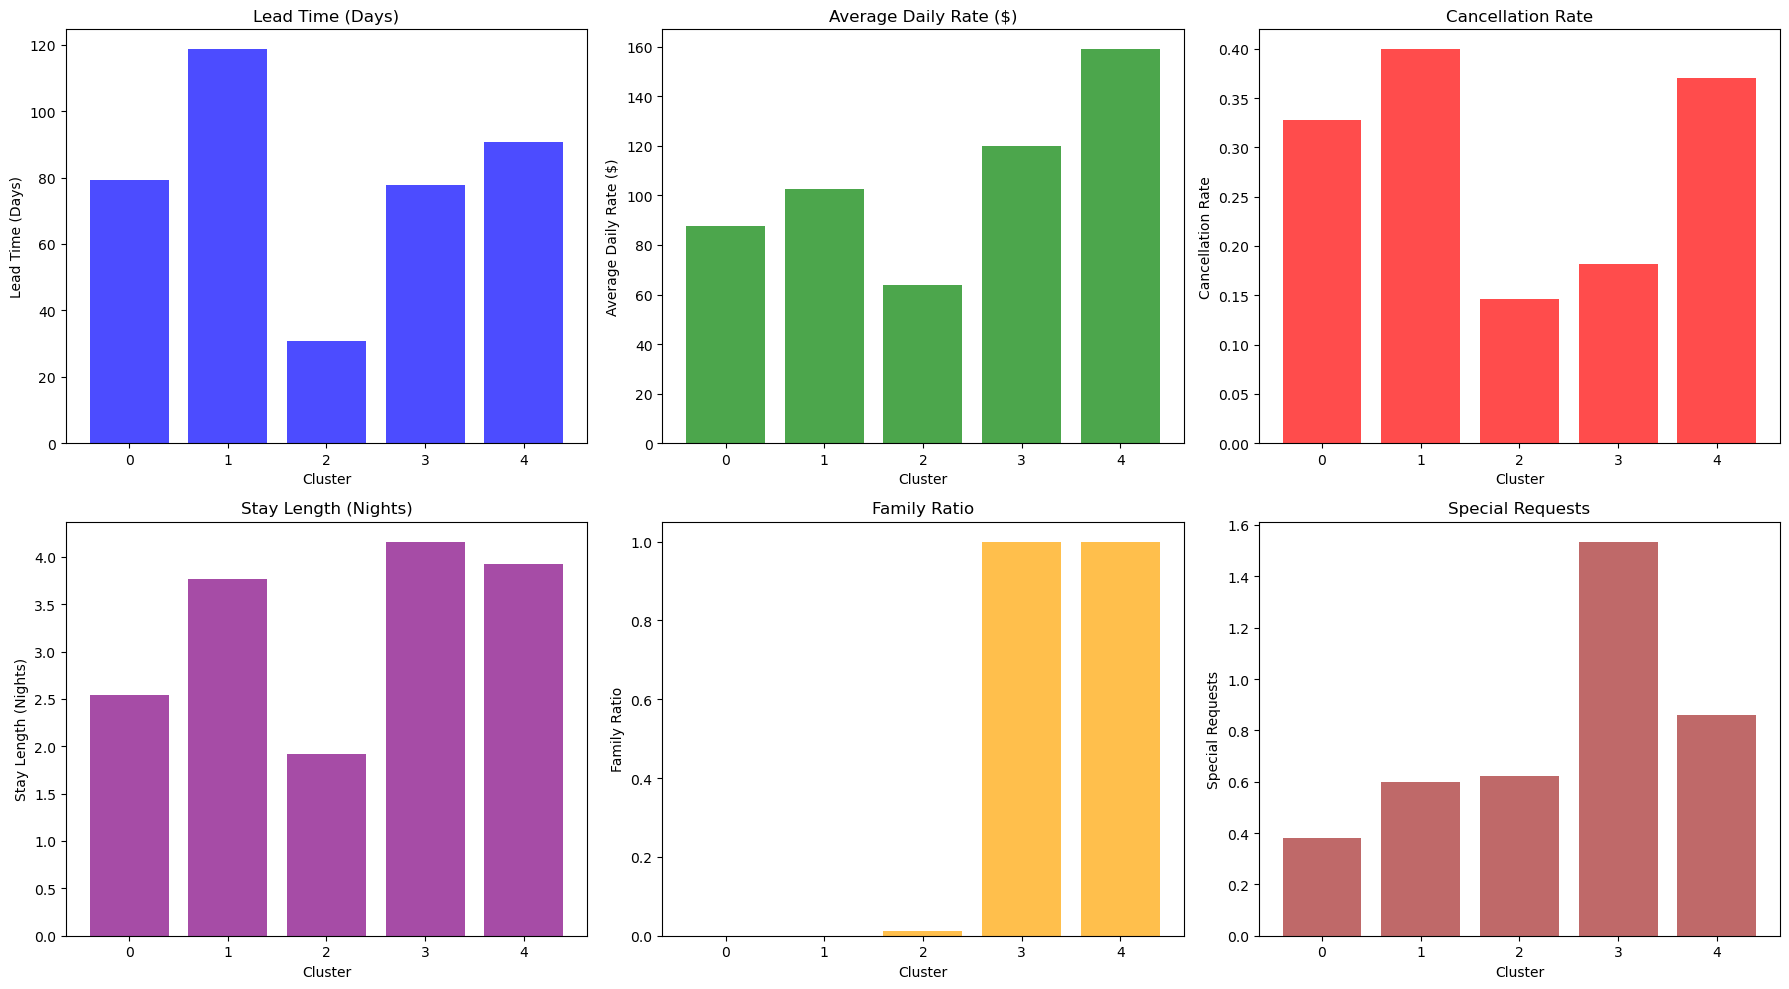

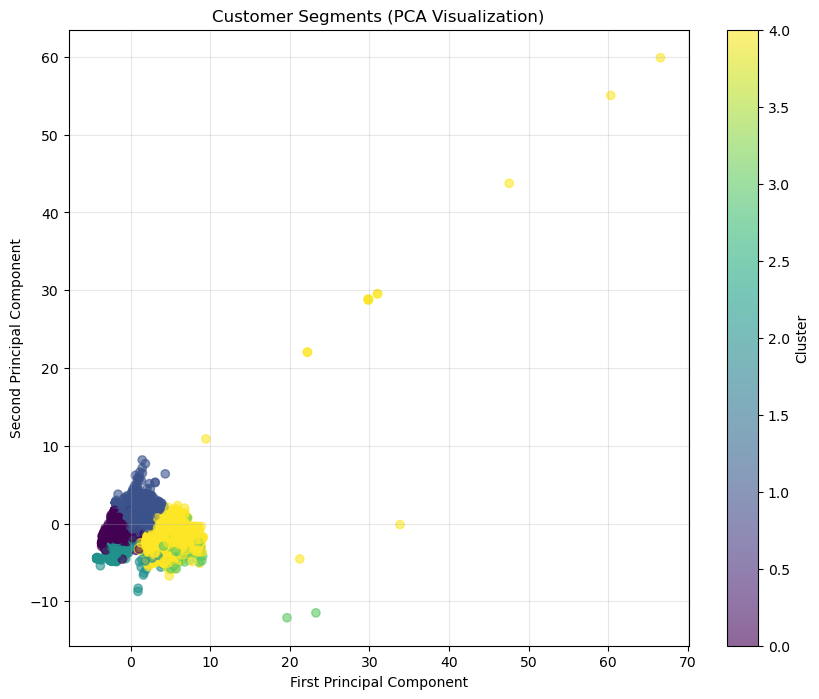

In [15]:
# Visualization 1: Cluster characteristics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = [
    ('avg_lead_time', 'Lead Time (Days)', 'blue'),
    ('avg_adr', 'Average Daily Rate ($)', 'green'),
    ('cancellation_rate', 'Cancellation Rate', 'red'),
    ('avg_stay_length', 'Stay Length (Nights)', 'purple'),
    ('family_ratio', 'Family Ratio', 'orange'),
    ('special_requests_avg', 'Special Requests', 'brown')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    row, col = idx // 3, idx % 3
    axes[row, col].bar(customer_profiles['cluster'], customer_profiles[metric], color=color, alpha=0.7)
    axes[row, col].set_title(title)
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel(title)

plt.tight_layout()
plt.show()

# Visualization 2: PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Customer Segments (PCA Visualization)')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
def generate_recommendations(customer_profiles):
    recommendations = []
    
    for _, profile in customer_profiles.iterrows():
        rec = {
            'cluster': profile['cluster'],
            'profile_name': profile['profile_name'],
            'segment_size': f"{profile['size']} customers ({profile['percentage']:.1f}%)",
            'targeted_actions': [],
            'investment_areas': [],
            'risk_management': []
        }
        
        # Business Travelers
        if "Business" in profile['profile_name']:
            rec['targeted_actions'] = [
                "Express check-in services",
                "Meeting room access packages",
                "Early breakfast options"
            ]
            rec['investment_areas'] = ["Premium WiFi", "Business center upgrades"]
        
        # Family Travelers  
        elif "Family" in profile['profile_name']:
            rec['targeted_actions'] = [
                "Family suite packages",
                "Kids activity programs",
                "Family dining offers"
            ]
            rec['investment_areas'] = ["Play areas", "Family amenities"]
        
        # High-risk segments
        if profile['cancellation_rate'] > 0.25:
            rec['risk_management'] = [
                "Stricter cancellation policies",
                "Deposit requirements",
                "Non-refundable rate options"
            ]
            
        recommendations.append(rec)
    
    return pd.DataFrame(recommendations)

# Generate recommendations
recommendations_df = generate_recommendations(customer_profiles)
print("\nSTRATEGIC RECOMMENDATIONS:")
for _, rec in recommendations_df.iterrows():
    print(f"\n--- {rec['profile_name']} (Cluster {rec['cluster']}) ---")
    print(f"Size: {rec['segment_size']}")
    print(f"Actions: {', '.join(rec['targeted_actions'])}")
    if rec['risk_management']:
        print(f"Risk: {', '.join(rec['risk_management'])}")


STRATEGIC RECOMMENDATIONS:

--- Standard Leisure Travelers (Cluster 0) ---
Size: 28982 customers (24.3%)
Actions: 
Risk: Stricter cancellation policies, Deposit requirements, Non-refundable rate options

--- High-Risk Advance Planners (Cluster 1) ---
Size: 77297 customers (64.8%)
Actions: 
Risk: Stricter cancellation policies, Deposit requirements, Non-refundable rate options

--- Standard Leisure Travelers (Cluster 2) ---
Size: 3759 customers (3.1%)
Actions: 

--- Family Vacationers (Cluster 3) ---
Size: 917 customers (0.8%)
Actions: Family suite packages, Kids activity programs, Family dining offers

--- Standard Leisure Travelers (Cluster 4) ---
Size: 8379 customers (7.0%)
Actions: 
Risk: Stricter cancellation policies, Deposit requirements, Non-refundable rate options


In [18]:
# Save all results
customer_profiles.to_csv('customer_segments.csv', index=False)
recommendations_df.to_csv('strategic_recommendations.csv', index=False)
hb.to_csv('hotel_data_with_clusters.csv', index=False)

print(f"\n✅ Analysis Complete!")
print(f"📊 Files saved:")
print(f"   - customer_segments.csv (Customer profiles)")
print(f"   - strategic_recommendations.csv (Business recommendations)")
print(f"   - hotel_data_with_clusters.csv (Original data with cluster labels)")


✅ Analysis Complete!
📊 Files saved:
   - customer_segments.csv (Customer profiles)
   - strategic_recommendations.csv (Business recommendations)
   - hotel_data_with_clusters.csv (Original data with cluster labels)


In [21]:
import pandas as pd
import numpy as np

marketing_spend_dict = {
    2015: {'City Hotel': 85000, 'Resort Hotel': 120000},
    2016: {'City Hotel': 92000, 'Resort Hotel': 135000},
    2017: {'City Hotel': 105000, 'Resort Hotel': 128000},
    2018: {'City Hotel': 98000, 'Resort Hotel': 142000}
}

# Add marketing spend column
hb['marketing_spend'] = hb.apply(
    lambda row: marketing_spend_dict.get(row['arrival_date_year'], {}).get(row['hotel'], 0),
    axis=1
)

In [24]:
# Display the marketing spend list
marketing_spend_list = []
for year, hotels in marketing_spend_dict.items():
    for hotel_type, spend in hotels.items():
        marketing_spend_list.append({
            'year': year,
            'hotel': hotel_type,
            'marketing_spend': spend
        })

marketing_list_df = pd.DataFrame(marketing_spend_list)
print("Marketing Spend List:")
print(marketing_list_df)

# Verify the new column in main dataframe
print(f"\nMarketing spend column statistics:")
print(hb.groupby(['hotel', 'arrival_date_year'])['marketing_spend'].first())

Marketing Spend List:
   year         hotel  marketing_spend
0  2015    City Hotel            85000
1  2015  Resort Hotel           120000
2  2016    City Hotel            92000
3  2016  Resort Hotel           135000
4  2017    City Hotel           105000
5  2017  Resort Hotel           128000
6  2018    City Hotel            98000
7  2018  Resort Hotel           142000

Marketing spend column statistics:
hotel         arrival_date_year
City Hotel    2015                  85000
              2016                  92000
              2017                 105000
Resort Hotel  2015                 120000
              2016                 135000
              2017                 128000
Name: marketing_spend, dtype: int64


In [51]:
# 1. Simple Marketing Spend Allocation by Country (proportional to bookings)
country_marketing = hb.groupby(['hotel', 'country']).agg(
    total_bookings=('country', 'count'),
    total_revenue=('adr', 'sum')  # Simple revenue estimate
).reset_index()

C:\Users\Madivoli Analytics\AppData\Local\Temp\ipykernel_7244\3853003743.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_marketing = hb.groupby(['hotel', 'country']).agg(


In [55]:
# Allocate marketing spend proportional to bookings per hotel type
for hotel_type in country_marketing['hotel'].unique():
    hotel_total_bookings = country_marketing[country_marketing['hotel'] == hotel_type]['total_bookings'].sum()
    hotel_marketing_spend = hb[hb['hotel'] == hotel_type]['marketing_spend'].iloc[0]
    
    country_marketing.loc[country_marketing['hotel'] == hotel_type, 'marketing_spend'] = (
        country_marketing['total_bookings'] / hotel_total_bookings * hotel_marketing_spend
    )

print("Marketing Spend Allocation by Country and Hotel Type:")
print(country_marketing[['hotel', 'country', 'total_bookings', 'marketing_spend', 'total_revenue']].head(10))

Marketing Spend Allocation by Country and Hotel Type:
        hotel country  total_bookings  marketing_spend  total_revenue
0  City Hotel     ABW               2     1.277988e-37         256.68
1  City Hotel     AGO             338     2.159800e-35       38871.48
2  City Hotel     AIA               1     6.389941e-38         265.00
3  City Hotel     ALB               9     5.750947e-37         757.09
4  City Hotel     AND               2     1.277988e-37         190.00
5  City Hotel     ARE              40     2.555976e-36        4977.68
6  City Hotel     ARG             157     1.003221e-35       18256.64
7  City Hotel     ARM               6     3.833965e-37         695.20
8  City Hotel     ASM               1     6.389941e-38          72.07
9  City Hotel     ATA               2     1.277988e-37         268.50


In [39]:
print(hb.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel        False        342               2015               July   
1  Resort Hotel        False        737               2015               July   
2  Resort Hotel        False          7               2015               July   
3  Resort Hotel        False         13               2015               July   
4  Resort Hotel        False         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0        

In [ ]:
Calculating the Cost Per Acquisition (CPA)

In [54]:
hb['cpa'] = hb['marketing_spend'] / hb.groupby(['hotel', 'arrival_date_year'])['hotel'].transform('count')

print("1. Cost Per Acquisition (CPA) by Hotel Type and Year:")
cpa_summary = hb.groupby(['hotel', 'arrival_date_year']).agg({
    'marketing_spend': 'first',
    'cpa': 'mean'
}).reset_index()
print(cpa_summary)

1. Cost Per Acquisition (CPA) by Hotel Type and Year:
          hotel  arrival_date_year  marketing_spend           cpa
0    City Hotel               2015     5.065753e-33  3.703036e-37
1    City Hotel               2016     5.425469e-37  1.423634e-41
2    City Hotel               2017     1.172312e-35  4.264969e-40
3  Resort Hotel               2015     6.322532e-31  7.604682e-35
4  Resort Hotel               2016     5.155725e-34  2.777270e-38
5  Resort Hotel               2017     1.067254e-32  8.098142e-37


C:\Users\Madivoli Analytics\AppData\Local\Temp\ipykernel_7244\267713700.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hb['cpa'] = hb['marketing_spend'] / hb.groupby(['hotel', 'arrival_date_year'])['hotel'].transform('count')
C:\Users\Madivoli Analytics\AppData\Local\Temp\ipykernel_7244\267713700.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cpa_summary = hb.groupby(['hotel', 'arrival_date_year']).agg({


In [83]:
print(hba.head(5))

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel        False        342               2015               July   
1  Resort Hotel        False        737               2015               July   
2  Resort Hotel        False          7               2015               July   
3  Resort Hotel        False         13               2015               July   
4  Resort Hotel        False         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  arrival_date  \
0                        0                     0       2  ...    2015-07-01   
1     